# НИР3. Анализ экспериментальных данных

Ноутбук повторяет структуру глав 3–4 отчёта НИР2 (загрузка → GPU → CPU → ввод →
масштабирование), но на исправленном стенде, на трёх платформах и с
проверкой значимости. В конце — проверка гипотез H1–H3.

**Как читать результаты**

* **Единица измерения — прогон.** Из каждого прогона берётся одно число
  (например, медиана времени кадра за 30 с). В таблицах показателей —
  медиана по прогонам, то есть значение «типичного» прогона.
* **Сравнение с three.js** — отношение медиан (×1,00 — одинаково, ×2,00 —
  вдвое больше) с 95% доверительным интервалом и p-значением критерия
  Манна–Уитни (с поправкой Холма на число сравнений в разделе).
* **Вывод по одному правилу:** «≈ равны» — весь интервал внутри ±5%;
  «больше / меньше на X%» — различие значимо; «не ясно» — данных не хватает
  ни для одного вывода.

Повторов на вариант: S1 — 10 (на каждую точку нагрузки), S2 — 15, S3 — 30,
S4 — 20, S5 — 8.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from nirlib import config as C
from nirlib.load import load, frames
from nirlib.compare import compare, conclude, medians
from nirlib import plots as P

P.setup()
C.TABLE_DIR.mkdir(exist_ok=True)
runs, levels, bundles = load()
PLATFORMS = C.PLATFORMS
V = C.VARIANTS


def show(df, name=None, index=True, digits=3):
    if name:
        df.to_csv(C.TABLE_DIR / f"{name}.csv", index=index)
    display(Markdown(df.to_markdown(index=index, floatfmt=f".{digits}g")))


def ratio_table(cmp, with_load=False):
    # сравнения в читаемом виде: одна строка — один вариант на одной платформе
    t = pd.DataFrame({
        "платформа": cmp["platform"].map(PLATFORMS),
        **({"точка": cmp["load"]} if with_load else {}),
        "вариант": cmp["label"].map(V),
        "отношение к three.js [95% ДИ]": [f"×{r:.2f} [{lo:.2f}–{hi:.2f}]" if np.isfinite(r) else "—"
                                          for r, lo, hi in zip(cmp["ratio"], cmp["lo"], cmp["hi"])],
        "p (Холм)": cmp["p_holm"].map(lambda p: "—" if not np.isfinite(p) else ("< 0,001" if p < 0.001 else f"{p:.3f}")),
        "вывод": cmp["вывод"],
    })
    return t


count = runs.groupby(["platform", "scenario"]).size().unstack().rename(index=PLATFORMS)
show(count, "00_runs")

| platform              |   s1 |   s2 |   s3 |   s4 |   s5 |
|:----------------------|-----:|-----:|-----:|-----:|-----:|
| AMD Ryzen 5 · Chrome  |   80 |   75 |   60 |   80 |   32 |
| AMD Ryzen 5 · Firefox |   80 |   75 |   60 |   80 |   32 |
| Apple M4 · Chrome     |   80 |   75 |   60 |   80 |   32 |

## 1. Размер кода и холодный старт (S3)

Сцена S3 — 100 статичных объектов, построение внутри первого кадра, 30 холодных
загрузок на реализацию. Время до первого кадра раскладывается на две части:
загрузку и исполнение бандла (`js_ready`) и инициализацию сцены до отправки
первого кадра (`init`).

In [2]:
b = bundles.groupby("impl")[["raw_kb", "gzip_kb", "brotli_kb"]].first().loc[["threejs", "r3f"]]
b.loc["R3F / three.js"] = b.loc["r3f"] / b.loc["threejs"]
b.columns = ["код, КБ", "gzip, КБ", "brotli, КБ"]
show(b.rename(index=V), "01_bundle")

s3_metrics = {"ttfr_submit_ms": "время до первого кадра, мс", "js_ready_ms": "загрузка и исполнение бандла, мс",
              "init_ms": "инициализация сцены, мс", "first_frame_render_ms": "рендер первого кадра, мс",
              "heap_mb_at_ttfr": "память JS к первому кадру, МБ", "tbt_total_ms": "время блокировки (TBT), мс"}
show(medians(runs, "s3", s3_metrics, ["threejs", "r3f"], PLATFORMS).rename(columns=V), "01_s3_table")

| impl           |   код, КБ |   gzip, КБ |   brotli, КБ |
|:---------------|----------:|-----------:|-------------:|
| three.js       | 555       |     140    |       115    |
| R3F            |   1.1e+03 |     299    |       231    |
| R3F / three.js |   1.98    |       2.13 |         2.01 |

|                                                               |   three.js |   R3F |
|:--------------------------------------------------------------|-----------:|------:|
| ('Apple M4 · Chrome', 'время до первого кадра, мс')           |      102   | 229   |
| ('Apple M4 · Chrome', 'загрузка и исполнение бандла, мс')     |       43   |  86.5 |
| ('Apple M4 · Chrome', 'инициализация сцены, мс')              |       58.7 | 141   |
| ('Apple M4 · Chrome', 'рендер первого кадра, мс')             |       25.4 |  21.1 |
| ('Apple M4 · Chrome', 'память JS к первому кадру, МБ')        |       12.2 |  16.5 |
| ('Apple M4 · Chrome', 'время блокировки (TBT), мс')           |        0   |   0   |
| ('AMD Ryzen 5 · Chrome', 'время до первого кадра, мс')        |      291   | 490   |
| ('AMD Ryzen 5 · Chrome', 'загрузка и исполнение бандла, мс')  |      115   | 209   |
| ('AMD Ryzen 5 · Chrome', 'инициализация сцены, мс')           |      175   | 274   |
| ('AMD Ryzen 5 · Chrome', 'рендер первого кадра, мс')          |       77.5 |  58.3 |
| ('AMD Ryzen 5 · Chrome', 'память JS к первому кадру, МБ')     |       13.7 |  16.1 |
| ('AMD Ryzen 5 · Chrome', 'время блокировки (TBT), мс')        |      105   |  81   |
| ('AMD Ryzen 5 · Firefox', 'время до первого кадра, мс')       |      712   | 901   |
| ('AMD Ryzen 5 · Firefox', 'загрузка и исполнение бандла, мс') |      405   | 524   |
| ('AMD Ryzen 5 · Firefox', 'инициализация сцены, мс')          |      300   | 376   |
| ('AMD Ryzen 5 · Firefox', 'рендер первого кадра, мс')         |      185   | 141   |
| ('AMD Ryzen 5 · Firefox', 'память JS к первому кадру, МБ')    |      nan   | nan   |
| ('AMD Ryzen 5 · Firefox', 'время блокировки (TBT), мс')       |      nan   | nan   |

findfont: Failed to find font weight semibold for Helvetica Neue, now using 700.


findfont: Failed to find font weight semibold for Helvetica Neue, now using 700.


| платформа             | показатель                       | вариант   | отношение к three.js [95% ДИ]   | p (Холм)   | вывод          |
|:----------------------|:---------------------------------|:----------|:--------------------------------|:-----------|:---------------|
| AMD Ryzen 5 · Chrome  | время до первого кадра, мс       | R3F       | ×1.69 [1.64–1.82]               | < 0,001    | больше на 69%  |
| AMD Ryzen 5 · Firefox | время до первого кадра, мс       | R3F       | ×1.26 [1.22–1.30]               | < 0,001    | больше на 26%  |
| Apple M4 · Chrome     | время до первого кадра, мс       | R3F       | ×2.23 [1.69–2.31]               | < 0,001    | больше на 123% |
| AMD Ryzen 5 · Chrome  | загрузка и исполнение бандла, мс | R3F       | ×1.81 [1.74–2.12]               | < 0,001    | больше на 81%  |
| AMD Ryzen 5 · Firefox | загрузка и исполнение бандла, мс | R3F       | ×1.29 [1.21–1.36]               | < 0,001    | больше на 29%  |
| Apple M4 · Chrome     | загрузка и исполнение бандла, мс | R3F       | ×2.01 [1.93–2.07]               | < 0,001    | больше на 101% |
| AMD Ryzen 5 · Chrome  | инициализация сцены, мс          | R3F       | ×1.57 [1.51–1.62]               | < 0,001    | больше на 57%  |
| AMD Ryzen 5 · Firefox | инициализация сцены, мс          | R3F       | ×1.25 [1.06–1.40]               | < 0,001    | больше на 25%  |
| Apple M4 · Chrome     | инициализация сцены, мс          | R3F       | ×2.40 [1.55–2.56]               | < 0,001    | больше на 140% |

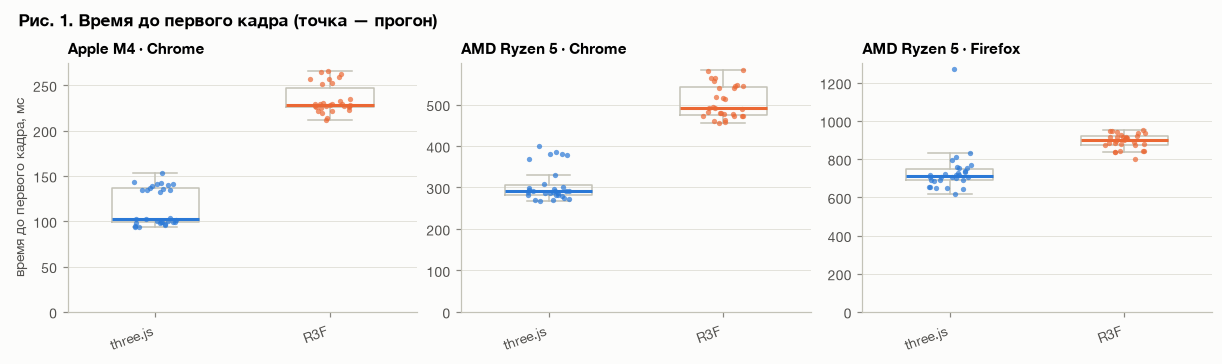

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for ax, (p, title) in zip(axes, PLATFORMS.items()):
    P.runs_by_variant(ax, runs[(runs["scenario"] == "s3") & (runs["platform"] == p)], "ttfr_submit_ms", ["threejs", "r3f"])
    ax.set_title(title)
    ax.set_ylim(bottom=0)
axes[0].set_ylabel("время до первого кадра, мс")
fig.suptitle("Рис. 1. Время до первого кадра (точка — прогон)", x=0.01, ha="left", fontweight="semibold")
P.save(fig, "01_s3_ttfr")

s3 = conclude(pd.concat([compare(runs, "s3", m) for m in ["ttfr_submit_ms", "js_ready_ms", "init_ms"]]))
s3.insert(0, "показатель", s3.pop("metric").map(s3_metrics))
t = ratio_table(s3)
t.insert(1, "показатель", s3["показатель"].values)
show(t, "01_s3_compare", index=False)

R3F стартует медленнее на всех платформах: время до первого кадра больше в
1,3–2,2 раза. Растут обе части — и загрузка с исполнением бандла (он больше
в 2,1 раза), и инициализация сцены (React строит дерево компонентов до
первого кадра). Первый кадр R3F рисует даже быстрее — сцена к этому моменту
уже собрана. В абсолютных числах разница 0,13–0,2 с, что далеко от бюджета
LCP 2,5 с. Long tasks (TBT) заметны только на AMD · Chrome, и у обеих
реализаций сопоставимы; в Firefox API long tasks нет.

## 2. Нагрузка на графический процессор (S1)

В НИР2 S1 был одной точкой. Теперь это свип по характеру нагрузки: каждая
точка нагружает свою часть конвейера. Сцена статична, работает только камера,
поэтому фреймворку в кадре делать почти нечего — **различий здесь быть не
должно**. Это одновременно проверка гипотезы H1 и контроль стенда.

| Точка | Что нагружено | Конфигурация |
|---|---|---|
| A | заливка пикселей | 300 объектов, тени 4096, ×2 разрешение |
| B | вершины | 3000 объектов, ½ разрешения |
| C | число вызовов отрисовки (CPU в рендерере) | 3000 объектов, упрощённая геометрия |
| D | исходная сцена НИР2 | 3000 объектов |

| платформа             | точка   | вариант   | отношение к three.js [95% ДИ]   | p (Холм)   | вывод   |
|:----------------------|:--------|:----------|:--------------------------------|:-----------|:--------|
| AMD Ryzen 5 · Chrome  | A       | R3F ref   | ×1.01 [1.01–1.03]               | 0.036      | ≈ равны |
| AMD Ryzen 5 · Chrome  | B       | R3F ref   | ×1.00 [0.99–1.01]               | 0.372      | ≈ равны |
| AMD Ryzen 5 · Chrome  | C       | R3F ref   | ×1.02 [1.00–1.02]               | 0.052      | ≈ равны |
| AMD Ryzen 5 · Chrome  | D       | R3F ref   | ×1.00 [1.00–1.00]               | 0.372      | ≈ равны |
| AMD Ryzen 5 · Firefox | A       | R3F ref   | ×0.99 [0.98–0.99]               | < 0,001    | ≈ равны |
| AMD Ryzen 5 · Firefox | B       | R3F ref   | ×1.04 [0.97–1.05]               | 0.427      | не ясно |
| AMD Ryzen 5 · Firefox | C       | R3F ref   | ×0.96 [0.93–1.02]               | 0.208      | не ясно |
| AMD Ryzen 5 · Firefox | D       | R3F ref   | ×0.99 [0.98–1.00]               | 0.094      | ≈ равны |
| Apple M4 · Chrome     | A       | R3F ref   | ×1.00 [0.99–1.02]               | 1.000      | ≈ равны |
| Apple M4 · Chrome     | B       | R3F ref   | ×0.99 [0.99–1.00]               | 0.161      | ≈ равны |
| Apple M4 · Chrome     | C       | R3F ref   | ×0.99 [0.99–1.01]               | 0.945      | ≈ равны |
| Apple M4 · Chrome     | D       | R3F ref   | ×0.99 [0.99–1.00]               | 0.050      | ≈ равны |

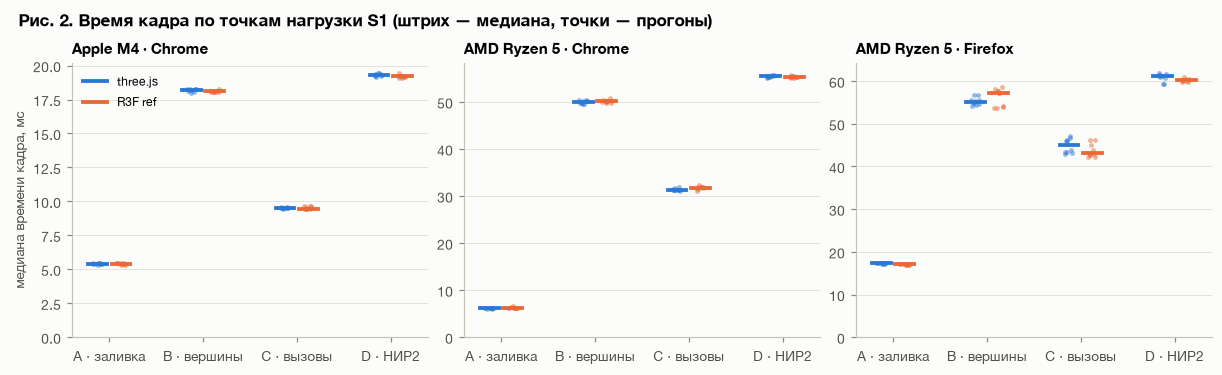

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.3))
s1 = runs[runs["scenario"] == "s1"]
for ax, (p, title) in zip(axes, PLATFORMS.items()):
    for k, lab in enumerate(["threejs", "r3f-ref"]):
        g = s1[(s1["platform"] == p) & (s1["label"] == lab)]
        for i, pt in enumerate("ABCD"):
            vals = g.loc[g["load"] == pt, "frame_ms_median"]
            x = i + (k - 0.5) * 0.25
            ax.scatter(x + np.random.default_rng(i).uniform(-0.05, 0.05, len(vals)), vals, s=10, color=C.COLORS[lab], alpha=0.5, lw=0)
            ax.plot([x - 0.1, x + 0.1], [vals.median()] * 2, color=C.COLORS[lab], lw=2.5,
                    label=V[lab] if i == 0 else None)
    ax.set_xticks(range(4), ["A · заливка", "B · вершины", "C · вызовы", "D · НИР2"])
    ax.set_ylim(bottom=0)
    ax.set_title(title)
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("медиана времени кадра, мс")
axes[0].legend()
fig.suptitle("Рис. 2. Время кадра по точкам нагрузки S1 (штрих — медиана, точки — прогоны)", x=0.01, ha="left", fontweight="semibold")
P.save(fig, "02_s1_frame")

s1c = conclude(compare(runs, "s1", "frame_ms_median", loads=list("ABCD")))
show(ratio_table(s1c.sort_values(["platform", "load"]), with_load=True), "02_s1_compare", index=False)

**Чем ограничен кадр.** GPU-время снимается таймером WebGL (есть в Chrome,
нет в Firefox). Если GPU-время больше времени кадра или близко к нему, узкое
место — видеокарта; если заметно меньше — процессор.

In [5]:
s1t = (s1[s1["label"].isin(["threejs", "r3f-ref"])]
       .assign(gpu_to_frame=lambda d: d["gpu_ms_median"] / d["frame_ms_median"])
       .groupby(["platform", "load", "label"])[["frame_ms_median", "gpu_ms_median", "gpu_to_frame"]].median()
       .unstack("label"))
s1t.columns = [f"{V[l]}: {m}" for m, l in s1t.columns]
s1t = s1t.rename(columns=lambda c: c.replace("frame_ms_median", "кадр, мс").replace("gpu_ms_median", "GPU, мс")
                 .replace("gpu_to_frame", "GPU / кадр"))
s1t.index = s1t.index.set_names(["платформа", "точка"])
show(s1t[s1t.index.get_level_values(0) != "amd-ryzen-5 · firefox"].rename(index=PLATFORMS), "02_s1_table")

|                               |   R3F ref: кадр, мс |   three.js: кадр, мс |   R3F ref: GPU, мс |   three.js: GPU, мс |   R3F ref: GPU / кадр |   three.js: GPU / кадр |
|:------------------------------|--------------------:|---------------------:|-------------------:|--------------------:|----------------------:|-----------------------:|
| ('AMD Ryzen 5 · Chrome', 'A') |                6.22 |                 6.14 |              12.1  |               12.1  |                 1.94  |                  1.97  |
| ('AMD Ryzen 5 · Chrome', 'B') |               50.2  |                50    |              49.5  |               49.2  |                 0.985 |                  0.983 |
| ('AMD Ryzen 5 · Chrome', 'C') |               31.8  |                31.3  |              26.6  |               26.2  |                 0.834 |                  0.838 |
| ('AMD Ryzen 5 · Chrome', 'D') |               55.4  |                55.5  |              54.3  |               54.2  |                 0.98  |                  0.977 |
| ('Apple M4 · Chrome', 'A')    |                5.42 |                 5.4  |               8.07 |                8.04 |                 1.49  |                  1.49  |
| ('Apple M4 · Chrome', 'B')    |               18.1  |                18.2  |              21.1  |               21.1  |                 1.17  |                  1.16  |
| ('Apple M4 · Chrome', 'C')    |                9.47 |                 9.52 |               5.93 |                5.93 |                 0.626 |                  0.622 |
| ('Apple M4 · Chrome', 'D')    |               19.2  |                19.3  |              25.3  |               25.3  |                 1.32  |                  1.31  |

Во всех точках, где удалось сделать вывод, R3F и three.js практически равны
(в пределах ±5%). Это касается и точки C, где кадр держит процессор, а не
видеокарта (GPU / кадр < 1): обход сцены при 5600 вызовах отрисовки у R3F не
дороже. В Firefox разброс между прогонами больше, поэтому в точках B и C
вывод «не ясно»: разница не обнаружена, но и равенство с точностью 5% не
доказано.

## 3. Нагрузка на центральный процессор (S2)

3000 объектов, каждый меняет положение и поворот каждый кадр. Здесь работа
фреймворка максимальна, поэтому сравниваются способы организации обновлений в R3F:

| Вариант | Как обновляется сцена |
|---|---|
| R3F ref | `useFrame` в каждом компоненте, мутация через ref — рекомендация R3F |
| R3F ref-central | один `useFrame` на все объекты |
| R3F state | `setState` каждый кадр — антипаттерн |
| R3F ref + parent-state | как ref, но в родителе `<Canvas>` state меняется 2 раза в секунду — антипаттерн |

In [6]:
S2V = ["threejs", "r3f-ref", "r3f-ref-central", "r3f-state", "r3f-ref+parent-state"]
s2_metrics = {"fps_mean": "FPS, среднее", "frame_ms_median": "время кадра, медиана, мс",
              "frame_ms_stddev": "время кадра, СКО, мс", "fps_p1_low": "FPS, нижний 1%",
              "frame_ms_p99": "время кадра, p99, мс", "update_ms_median": "обновление сцены, мс",
              "heap_mb_peak": "память JS, пик, МБ"}
show(medians(runs, "s2", s2_metrics, S2V, PLATFORMS).rename(columns=V), "03_s2_table")

|                                                       |   three.js |   R3F ref |   R3F ref-central |   R3F state |   R3F ref + parent-state |
|:------------------------------------------------------|-----------:|----------:|------------------:|------------:|-------------------------:|
| ('Apple M4 · Chrome', 'FPS, среднее')                 |    208     |   206     |           223     |      73.4   |                  207     |
| ('Apple M4 · Chrome', 'время кадра, медиана, мс')     |      4.83  |     4.84  |             4.5   |      13.2   |                    4.75  |
| ('Apple M4 · Chrome', 'время кадра, СКО, мс')         |      0.174 |     0.131 |             0.158 |       1.18  |                    0.884 |
| ('Apple M4 · Chrome', 'FPS, нижний 1%')               |    186     |   178     |           191     |      49.7   |                   74.5   |
| ('Apple M4 · Chrome', 'время кадра, p99, мс')         |      5.14  |     5.14  |             4.75  |      18.4   |                    7.78  |
| ('Apple M4 · Chrome', 'обновление сцены, мс')         |      0.47  |     0.715 |             0.435 |       0.845 |                    0.585 |
| ('Apple M4 · Chrome', 'память JS, пик, МБ')           |    108     |    90.3   |           105     |     313     |                  195     |
| ('AMD Ryzen 5 · Chrome', 'FPS, среднее')              |     74.8   |    71.7   |            75.3   |      23.9   |                   67.2   |
| ('AMD Ryzen 5 · Chrome', 'время кадра, медиана, мс')  |     12.9   |    13.6   |            13     |      39.6   |                   13.6   |
| ('AMD Ryzen 5 · Chrome', 'время кадра, СКО, мс')      |      0.975 |     1     |             1     |       4.96  |                    4.9   |
| ('AMD Ryzen 5 · Chrome', 'FPS, нижний 1%')            |     52.5   |    50.3   |            51.7   |      13.9   |                   21.7   |
| ('AMD Ryzen 5 · Chrome', 'время кадра, p99, мс')      |     16.9   |    18.1   |            17.3   |      63.9   |                   41.1   |
| ('AMD Ryzen 5 · Chrome', 'обновление сцены, мс')      |      1.13  |     1.43  |             0.985 |       1.85  |                    1.31  |
| ('AMD Ryzen 5 · Chrome', 'память JS, пик, МБ')        |     83.4   |    81.8   |            78.9   |     314     |                  204     |
| ('AMD Ryzen 5 · Firefox', 'FPS, среднее')             |     51.7   |    49.9   |            52.6   |      21.7   |                   45.5   |
| ('AMD Ryzen 5 · Firefox', 'время кадра, медиана, мс') |     18.9   |    19.6   |            18.5   |      51.9   |                   19.6   |
| ('AMD Ryzen 5 · Firefox', 'время кадра, СКО, мс')     |      1.25  |     1.13  |             1.41  |      27.4   |                    9.92  |
| ('AMD Ryzen 5 · Firefox', 'FPS, нижний 1%')           |     37.8   |    39     |            35.4   |       9.09  |                   12.3   |
| ('AMD Ryzen 5 · Firefox', 'время кадра, p99, мс')     |     23.7   |    24.2   |            23.6   |     106     |                   68.5   |
| ('AMD Ryzen 5 · Firefox', 'обновление сцены, мс')     |      1.24  |     1.98  |             1.32  |       1.76  |                    1.94  |
| ('AMD Ryzen 5 · Firefox', 'память JS, пик, МБ')       |    nan     |   nan     |           nan     |     nan     |                  nan     |

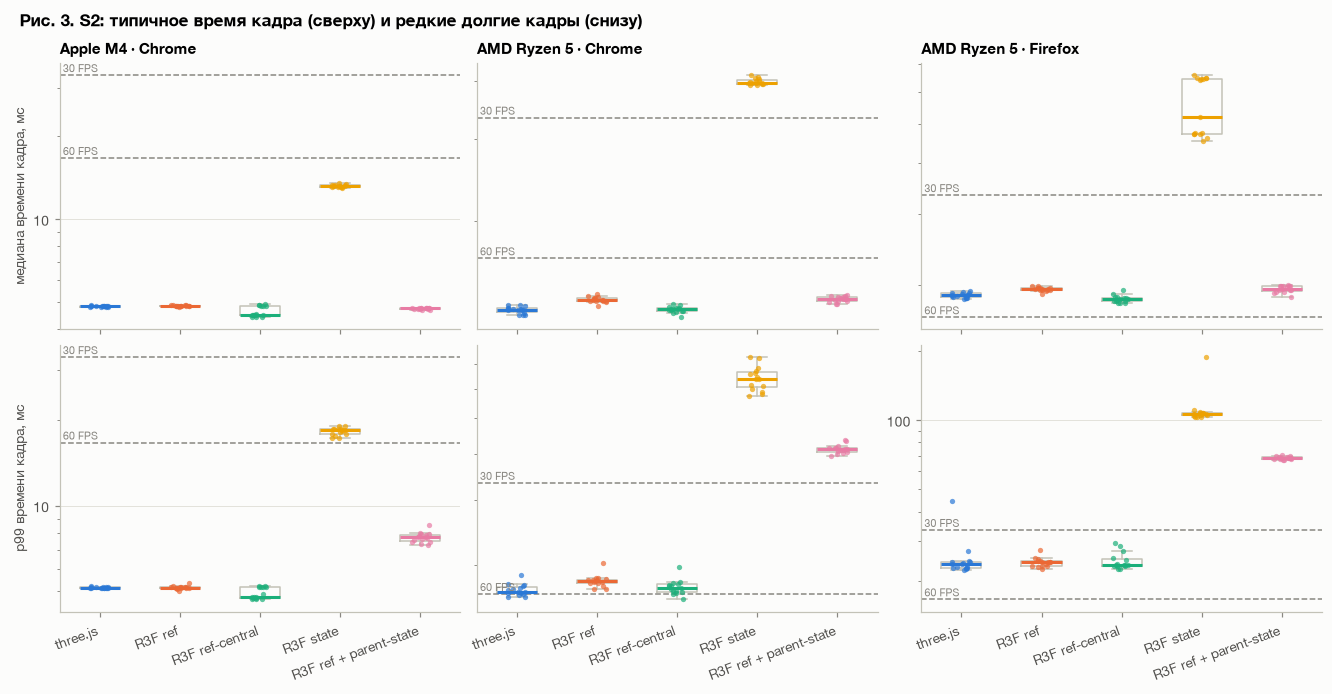

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6.2), sharex=True)
s2 = runs[runs["scenario"] == "s2"]
for j, (p, title) in enumerate(PLATFORMS.items()):
    for i, (m, lab) in enumerate([("frame_ms_median", "медиана времени кадра, мс"), ("frame_ms_p99", "p99 времени кадра, мс")]):
        ax = axes[i][j]
        P.runs_by_variant(ax, s2[s2["platform"] == p], m, S2V, log=True)
        P.fps_lines(ax)
        if j == 0:
            ax.set_ylabel(lab)
        if i == 0:
            ax.set_title(title)
fig.suptitle("Рис. 3. S2: типичное время кадра (сверху) и редкие долгие кадры (снизу)", x=0.01, ha="left", fontweight="semibold")
P.save(fig, "03_s2_frame")

**Откуда берутся долгие кадры у parent-state.** Фрагмент покадрового ряда
одного прогона на Apple M4: каждые 0,5 с, при каждом изменении state над
`<Canvas>`, React перерисовывает всё дерево сцены — это видно как пик.

| платформа             | показатель               | вариант                | отношение к three.js [95% ДИ]   | p (Холм)   | вывод           |
|:----------------------|:-------------------------|:-----------------------|:--------------------------------|:-----------|:----------------|
| AMD Ryzen 5 · Chrome  | время кадра, p99, мс     | R3F ref                | ×1.07 [1.03–1.09]               | 0.005      | больше на 7%    |
| AMD Ryzen 5 · Chrome  | время кадра, p99, мс     | R3F ref-central        | ×1.02 [0.98–1.05]               | 1.000      | не ясно         |
| AMD Ryzen 5 · Chrome  | время кадра, p99, мс     | R3F state              | ×3.77 [3.54–3.95]               | < 0,001    | больше на 277%  |
| AMD Ryzen 5 · Chrome  | время кадра, p99, мс     | R3F ref + parent-state | ×2.43 [2.35–2.47]               | < 0,001    | больше на 143%  |
| AMD Ryzen 5 · Chrome  | время кадра, СКО, мс     | R3F ref                | ×1.03 [0.92–1.18]               | 1.000      | не ясно         |
| AMD Ryzen 5 · Chrome  | время кадра, СКО, мс     | R3F ref-central        | ×1.03 [0.90–1.14]               | 1.000      | не ясно         |
| AMD Ryzen 5 · Chrome  | время кадра, СКО, мс     | R3F state              | ×5.09 [4.54–5.53]               | < 0,001    | больше на 409%  |
| AMD Ryzen 5 · Chrome  | время кадра, СКО, мс     | R3F ref + parent-state | ×5.02 [4.50–5.45]               | < 0,001    | больше на 402%  |
| AMD Ryzen 5 · Chrome  | время кадра, медиана, мс | R3F ref                | ×1.05 [1.04–1.06]               | < 0,001    | больше на 5%    |
| AMD Ryzen 5 · Chrome  | время кадра, медиана, мс | R3F ref-central        | ×1.00 [0.99–1.01]               | 1.000      | ≈ равны         |
| AMD Ryzen 5 · Chrome  | время кадра, медиана, мс | R3F state              | ×3.06 [3.03–3.13]               | < 0,001    | больше на 206%  |
| AMD Ryzen 5 · Chrome  | время кадра, медиана, мс | R3F ref + parent-state | ×1.05 [1.04–1.07]               | < 0,001    | больше на 5%    |
| AMD Ryzen 5 · Firefox | время кадра, p99, мс     | R3F ref                | ×1.02 [0.98–1.06]               | 1.000      | не ясно         |
| AMD Ryzen 5 · Firefox | время кадра, p99, мс     | R3F ref-central        | ×0.99 [0.97–1.06]               | 1.000      | не ясно         |
| AMD Ryzen 5 · Firefox | время кадра, p99, мс     | R3F state              | ×4.48 [4.37–4.67]               | < 0,001    | больше на 348%  |
| AMD Ryzen 5 · Firefox | время кадра, p99, мс     | R3F ref + parent-state | ×2.88 [2.82–3.01]               | < 0,001    | больше на 188%  |
| AMD Ryzen 5 · Firefox | время кадра, СКО, мс     | R3F ref                | ×0.91 [0.69–1.04]               | 0.744      | не ясно         |
| AMD Ryzen 5 · Firefox | время кадра, СКО, мс     | R3F ref-central        | ×1.14 [0.97–1.44]               | 1.000      | не ясно         |
| AMD Ryzen 5 · Firefox | время кадра, СКО, мс     | R3F state              | ×21.98 [21.09–24.01]            | < 0,001    | больше на 2098% |
| AMD Ryzen 5 · Firefox | время кадра, СКО, мс     | R3F ref + parent-state | ×7.97 [7.66–8.69]               | < 0,001    | больше на 697%  |
| AMD Ryzen 5 · Firefox | время кадра, медиана, мс | R3F ref                | ×1.04 [1.02–1.05]               | < 0,001    | больше на 4%    |
| AMD Ryzen 5 · Firefox | время кадра, медиана, мс | R3F ref-central        | ×0.98 [0.96–0.99]               | 0.034      | ≈ равны         |
| AMD Ryzen 5 · Firefox | время кадра, медиана, мс | R3F state              | ×2.75 [2.48–3.44]               | < 0,001    | больше на 175%  |
| AMD Ryzen 5 · Firefox | время кадра, медиана, мс | R3F ref + parent-state | ×1.04 [1.02–1.06]               | 0.001      | больше на 4%    |
| Apple M4 · Chrome     | время кадра, p99, мс     | R3F ref                | ×1.00 [0.99–1.00]               | 1.000      | ≈ равны         |
| Apple M4 · Chrome     | время кадра, p99, мс     | R3F ref-central        | ×0.92 [0.92–1.01]               | 1.000      | не ясно         |
| Apple M4 · Chrome     | время кадра, p99, мс     | R3F state              | ×3.59 [3.47–3.61]               | < 0,001    | больше на 259%  |
| Apple M4 · Chrome     | время кадра, p99, мс     | R3F ref + parent-state | ×1.51 [1.47–1.54]               | < 0,001    | больше на 51%   |
| Apple M4 · Chrome     | время кадра, СКО, мс     | R3F ref                | ×0.75 [0.72–0.77]               | < 0,001    | меньше на 25%   |
| Apple M4 · Chrome     | время кадра, СКО, мс     | R3F ref-central        | ×0.91 [0.86–1.01]               | 0.216      | не ясно         |
| Apple M4 · Chrome     | время кадра, СКО, мс     | R3F state              | ×6.80 [6.55–6.92]               | < 0,001    | больше на 580%  |
| Apple M4 · Chrome     | время кадра, СКО, мс     | R3F ref + parent-state | ×5.08 [4.85–5.17]               | < 0,001    | больше на 408%  |
| Apple M4 · Chrome     | время кадра, медиана, мс | R3F ref                | ×1.00 [1.00–1.01]               | 0.969      | ≈ равны         |
| Apple M4 · Chrome     | время кадра, медиана, мс | R3F ref-central        | ×0.93 [0.93–1.00]               | 1.000      | не ясно         |
| Apple M4 · Chrome     | время кадра, медиана, мс | R3F state              | ×2.74 [2.72–2.76]               | < 0,001    | больше на 174%  |
| Apple M4 · Chrome     | время кадра, медиана, мс | R3F ref + parent-state | ×0.98 [0.98–0.99]               | < 0,001    | ≈ равны         |

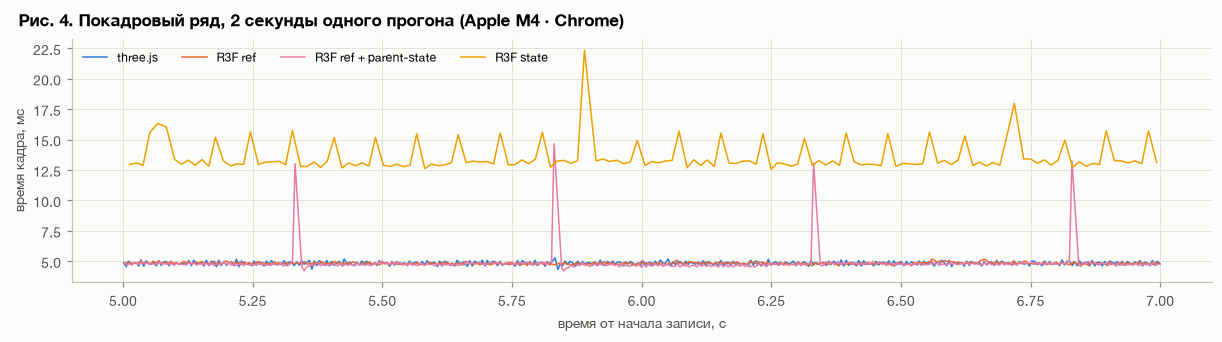

In [8]:
fig, ax = plt.subplots(figsize=(11, 3))
m4 = runs[(runs["scenario"] == "s2") & (runs["platform"] == "apple-m4 · chrome")]
for lab in ["threejs", "r3f-ref", "r3f-ref+parent-state", "r3f-state"]:
    f = frames(m4.loc[m4["label"] == lab, "file"].iloc[0])
    w = f[(f["start_ms"] > 5000) & (f["start_ms"] < 7000)]
    ax.plot(w["start_ms"] / 1000, w["frame_ms"], color=C.COLORS[lab], lw=1, label=V[lab])
ax.set_xlabel("время от начала записи, с")
ax.set_ylabel("время кадра, мс")
ax.legend(ncols=4, loc="upper left")
fig.suptitle("Рис. 4. Покадровый ряд, 2 секунды одного прогона (Apple M4 · Chrome)", x=0.01, ha="left", fontweight="semibold")
P.save(fig, "03_s2_timeseries")

s2c = conclude(pd.concat([compare(runs, "s2", m, variants=S2V[1:]) for m in ["frame_ms_median", "frame_ms_p99", "frame_ms_stddev"]]))
t = ratio_table(s2c)
t.insert(1, "показатель", s2c["metric"].map(s2_metrics).values)
show(t.sort_values(["платформа", "показатель"], kind="stable"), "03_s2_compare", index=False)

* **R3F ref** на Apple M4 по кадру совпадает с three.js, на AMD медленнее на
  4–5% — это цена `useFrame` в каждом из 3000 компонентов (фаза обновления
  сцены у R3F дольше). С одним центральным `useFrame` (**ref-central**) эта
  разница на AMD исчезает. На M4 ref-central даже немного быстрее (×0,93), но
  его прогоны разбились на две группы, и вывод «не ясно».
* **R3F state** (setState каждый кадр) — кадр в 2,7–3 раза длиннее, хвост
  (p99) — в 3,5–4,5 раза, 60 FPS недостижимы на AMD.
* **parent-state** не меняет типичный кадр, но даёт периодические пики
  (рис. 4): p99 в 1,5–2,9 раза выше. Именно эту картину в НИР2 приняли за
  «нестабильность R3F» — её причиной была строка статуса в React-state.

## 4. Отзывчивость на ввод (S4)

2000 объектов, клик подсвечивает объект. Клики подаются настоящим вводом
браузера в случайный момент кадра (в НИР2 событие синтезировалось в
JS, и задержка измерялась иначе). Задержка — от события до конца отрисовки
кадра с подсветкой. Она складывается из последовательных фаз (их сумма
точно равна задержке):

| Фаза | Что происходит |
|---|---|
| queue | событие ждёт обработки в очереди браузера |
| dispatch | обработчик клика: поиск объекта под курсором (raycast) и применение изменения; для R3F state сюда входит работа React по `setState` |
| commit | применение изменения после выхода из обработчика (отложенный commit React) |
| frame_wait | ожидание ближайшего кадра |
| render | отрисовка кадра с подсветкой |

Отдельно (в таблице) — **apply**: часть dispatch от попадания в объект до
применения изменения, то есть собственная стоимость способа обновления.

Варианты R3F: **ref** — ручной raycast и мутация, как в three.js; **events** —
встроенные события R3F (`onClick`); **state** — выбор объекта через `setState`.

|                                                                        |   three.js |   R3F ref |   R3F events |   R3F state |
|:-----------------------------------------------------------------------|-----------:|----------:|-------------:|------------:|
| ('Apple M4 · Chrome', 'задержка, медиана, мс')                         |      6.61  |     6.68  |        7.43  |       11.3  |
| ('Apple M4 · Chrome', 'задержка, p95, мс')                             |      8.51  |     8.46  |        9.07  |       13    |
| ('Apple M4 · Chrome', 'обработчик клика (dispatch), мс')               |      0.332 |     0.317 |        1.02  |        4.96 |
| ('Apple M4 · Chrome', '  из них применение изменения (apply), мс')     |      0     |     0     |        0.283 |        4.62 |
| ('Apple M4 · Chrome', 'попаданий по объекту за прогон')                |     54.5   |    54.5   |       53.5   |       53.5  |
| ('AMD Ryzen 5 · Chrome', 'задержка, медиана, мс')                      |     23.9   |    24.1   |       25.7   |       38.3  |
| ('AMD Ryzen 5 · Chrome', 'задержка, p95, мс')                          |     27     |    27.1   |       28.9   |       43.1  |
| ('AMD Ryzen 5 · Chrome', 'обработчик клика (dispatch), мс')            |      0.623 |     0.635 |        2.07  |       15.3  |
| ('AMD Ryzen 5 · Chrome', '  из них применение изменения (apply), мс')  |      0     |     0     |        0.658 |       14.5  |
| ('AMD Ryzen 5 · Chrome', 'попаданий по объекту за прогон')             |     50     |    49.5   |       49.5   |       48.5  |
| ('AMD Ryzen 5 · Firefox', 'задержка, медиана, мс')                     |     26.4   |    25.8   |       28.6   |       52.6  |
| ('AMD Ryzen 5 · Firefox', 'задержка, p95, мс')                         |     35.3   |    34.9   |       38.1   |       63.7  |
| ('AMD Ryzen 5 · Firefox', 'обработчик клика (dispatch), мс')           |      1.26  |     1.36  |        4.39  |       28.3  |
| ('AMD Ryzen 5 · Firefox', '  из них применение изменения (apply), мс') |      0     |     0     |        1.46  |       26.8  |
| ('AMD Ryzen 5 · Firefox', 'попаданий по объекту за прогон')            |     47     |    47     |       45     |       44    |

| платформа             | вариант    | отношение к three.js [95% ДИ]   | p (Холм)   | вывод         |
|:----------------------|:-----------|:--------------------------------|:-----------|:--------------|
| AMD Ryzen 5 · Chrome  | R3F ref    | ×1.01 [1.00–1.03]               | 0.024      | ≈ равны       |
| AMD Ryzen 5 · Chrome  | R3F events | ×1.08 [1.06–1.10]               | < 0,001    | больше на 8%  |
| AMD Ryzen 5 · Chrome  | R3F state  | ×1.60 [1.58–1.63]               | < 0,001    | больше на 60% |
| AMD Ryzen 5 · Firefox | R3F ref    | ×0.98 [0.94–1.03]               | 0.394      | не ясно       |
| AMD Ryzen 5 · Firefox | R3F events | ×1.08 [1.04–1.14]               | < 0,001    | больше на 8%  |
| AMD Ryzen 5 · Firefox | R3F state  | ×1.99 [1.92–2.09]               | < 0,001    | больше на 99% |
| Apple M4 · Chrome     | R3F ref    | ×1.01 [0.98–1.05]               | 0.267      | не ясно       |
| Apple M4 · Chrome     | R3F events | ×1.12 [1.07–1.16]               | < 0,001    | больше на 12% |
| Apple M4 · Chrome     | R3F state  | ×1.70 [1.67–1.76]               | < 0,001    | больше на 70% |

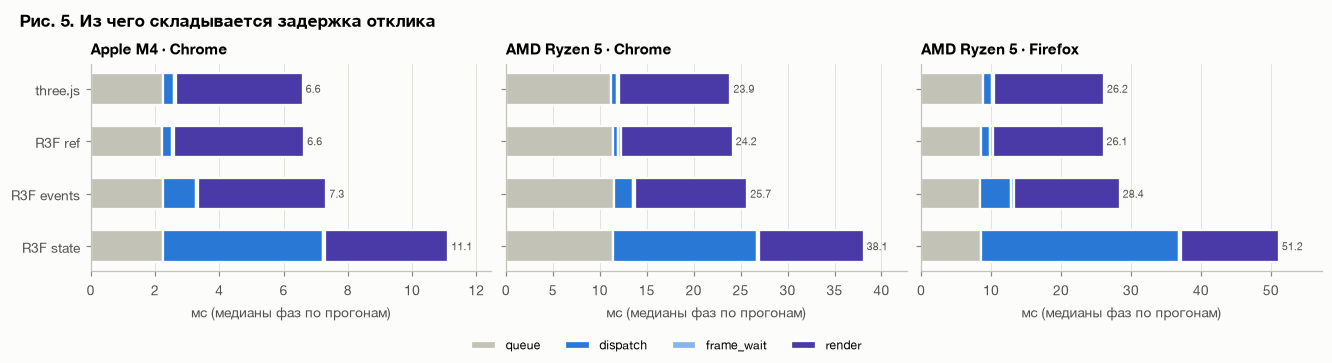

In [9]:
S4V = ["threejs", "r3f-ref", "r3f-events", "r3f-state"]
s4_metrics = {"latency_render_ms_median": "задержка, медиана, мс", "latency_render_ms_p95": "задержка, p95, мс",
              "dispatch_ms_median": "обработчик клика (dispatch), мс",
              "apply_ms_median": "  из них применение изменения (apply), мс",
              "ok": "попаданий по объекту за прогон"}
show(medians(runs, "s4", s4_metrics, S4V, PLATFORMS).rename(columns=V), "04_s4_table")

# только непересекающиеся фазы: apply лежит внутри dispatch и в сумму не входит;
# commit во всех вариантах ≈ 0 и на графике не показан
phases = ["queue_ms_median", "dispatch_ms_median", "frame_wait_ms_median", "render_ms_median"]
phase_colors = ["#c3c2b7", "#2a78d6", "#86b6ef", "#4a3aa7"]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
s4 = runs[runs["scenario"] == "s4"]
for ax, (p, title) in zip(axes, PLATFORMS.items()):
    med = s4[s4["platform"] == p].groupby("label")[phases].median().reindex(S4V)
    left = np.zeros(len(med))
    for ph, col in zip(phases, phase_colors):
        ax.barh(range(len(med)), med[ph], left=left, color=col, height=0.6, edgecolor=P.SURFACE, lw=1.5,
                label=ph.replace("_ms_median", ""))
        left += med[ph].to_numpy()
    for i, v in enumerate(left):
        ax.text(v, i, f" {v:.1f}", va="center", fontsize=7, color=P.INK2)
    ax.set_yticks(range(len(med)), [V[v] for v in S4V])
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel("мс (медианы фаз по прогонам)")
    ax.grid(axis="y", visible=False)
    ax.margins(x=0.12)
fig.legend(*axes[0].get_legend_handles_labels(), loc="outside lower center", ncols=4)
fig.suptitle("Рис. 5. Из чего складывается задержка отклика", x=0.01, ha="left", fontweight="semibold")
P.save(fig, "04_s4_phases")

s4c = conclude(compare(runs, "s4", "latency_render_ms_median", variants=S4V[1:]))
show(ratio_table(s4c), "04_s4_compare", index=False)

* **three.js и R3F ref не различаются** (×0,98–1,01) — ожидаемо для двух
  одинаковых императивных путей. На AMD · Chrome равенство доказано с
  точностью 5%, на остальных платформах интервал чуть шире. Разрыв 0,35
  против 4,85 мс из НИР2 был артефактом прежнего способа измерения.
* **События R3F** добавляют 8–12% — это 0,7–2,8 мс, заметно меньше одного
  кадра. Вся разница — в обработчике (dispatch): R3F сам обходит сцену,
  строит событие и вызывает `onClick`.
* **setState на клик** — задержка в 1,6–2 раза больше. Обработчик удлиняется
  в 15–25 раз: React синхронно перерисовывает компоненты прямо в нём (apply
  4,6 мс на M4, 14,5 мс на AMD). Отложенного commit нет ни в одном варианте.
* Во всех вариантах отклик укладывается в бюджет RAIL 100 мс с большим запасом.

## 5. Масштабирование (S5)

Анимация как в S2, число объектов растёт по сетке ×√2 (100 … 51 200), на
каждом уровне кадры записываются 3 с. Как и в НИР2, FPS здесь — пропускная
способность (сколько кадров система успевает сформировать за секунду при
снятом ограничении частоты), а не воспринимаемая плавность. Главный
показатель — **ёмкость**: при каком числе объектов кадр достигает 16,7 мс
(60 FPS) и 33,3 мс (30 FPS); harness находит его интерполяцией между уровнями.

|                                                  |   three.js |   R3F ref |   R3F ref-central |   R3F state |
|:-------------------------------------------------|-----------:|----------:|------------------:|------------:|
| ('Apple M4 · Chrome', 'объектов при 60 FPS')     |   9.06e+03 |  9.03e+03 |          8.66e+03 |    3.59e+03 |
| ('Apple M4 · Chrome', 'объектов при 30 FPS')     |   1.79e+04 |  1.81e+04 |          1.85e+04 |    6.17e+03 |
| ('AMD Ryzen 5 · Chrome', 'объектов при 60 FPS')  |   3.45e+03 |  3.47e+03 |          3.55e+03 |    1.19e+03 |
| ('AMD Ryzen 5 · Chrome', 'объектов при 30 FPS')  |   6.64e+03 |  6.71e+03 |          6.87e+03 |    2.37e+03 |
| ('AMD Ryzen 5 · Firefox', 'объектов при 60 FPS') |   2.58e+03 |  2.36e+03 |          2.47e+03 |  670        |
| ('AMD Ryzen 5 · Firefox', 'объектов при 30 FPS') |   5.04e+03 |  4.71e+03 |          4.87e+03 |    1.26e+03 |

| платформа             | вариант         | отношение к three.js [95% ДИ]   | p (Холм)   | вывод         |
|:----------------------|:----------------|:--------------------------------|:-----------|:--------------|
| AMD Ryzen 5 · Chrome  | R3F ref         | ×1.00 [0.98–1.03]               | 1.000      | ≈ равны       |
| AMD Ryzen 5 · Chrome  | R3F ref-central | ×1.03 [1.02–1.04]               | 0.021      | ≈ равны       |
| AMD Ryzen 5 · Chrome  | R3F state       | ×0.35 [0.34–0.35]               | 0.003      | меньше на 65% |
| AMD Ryzen 5 · Firefox | R3F ref         | ×0.92 [0.87–0.92]               | 0.003      | меньше на 8%  |
| AMD Ryzen 5 · Firefox | R3F ref-central | ×0.96 [0.91–0.97]               | 0.003      | меньше на 4%  |
| AMD Ryzen 5 · Firefox | R3F state       | ×0.26 [0.25–0.27]               | 0.003      | меньше на 74% |
| Apple M4 · Chrome     | R3F ref         | ×1.00 [0.96–1.05]               | 0.834      | ≈ равны       |
| Apple M4 · Chrome     | R3F ref-central | ×0.95 [0.91–1.01]               | 0.210      | не ясно       |
| Apple M4 · Chrome     | R3F state       | ×0.40 [0.39–0.41]               | < 0,001    | меньше на 60% |

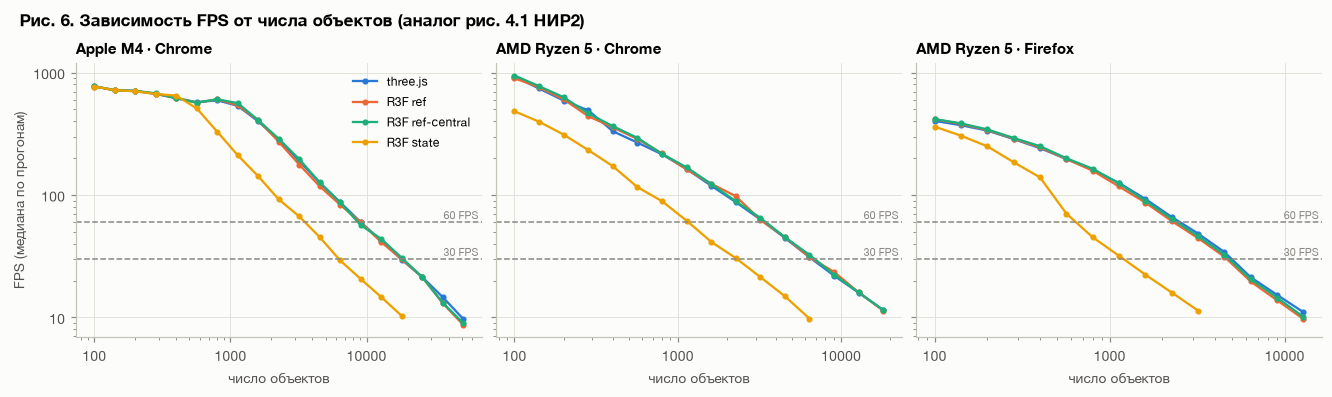

In [10]:
S5V = ["threejs", "r3f-ref", "r3f-ref-central", "r3f-state"]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
for ax, (p, title) in zip(axes, PLATFORMS.items()):
    g = levels[levels["platform"] == p]
    for lab in S5V:
        fps = (1000 / g[g["label"] == lab].groupby("N")["frame_ms_mean"].median())
        ax.plot(fps.index, fps.values, "-o", ms=3, color=C.COLORS[lab], label=V[lab])
    for y in (60, 30):
        ax.axhline(y, color=P.MUTED, ls="--", lw=1)
        ax.annotate(f"{y} FPS", (1, y), xycoords=("axes fraction", "data"), xytext=(-2, 2),
                    textcoords="offset points", ha="right", fontsize=7, color=P.MUTED)
    ax.set_xscale("log")
    ax.set_yscale("log")
    P.plain_log(ax.xaxis)
    P.plain_log(ax.yaxis)
    ax.set_xlabel("число объектов")
    ax.set_title(title)
axes[0].set_ylabel("FPS (медиана по прогонам)")
axes[0].legend()
fig.suptitle("Рис. 6. Зависимость FPS от числа объектов (аналог рис. 4.1 НИР2)", x=0.01, ha="left", fontweight="semibold")
P.save(fig, "05_s5_fps")

s5_metrics = {"capacity_fps60": "объектов при 60 FPS", "capacity_fps30": "объектов при 30 FPS"}
show(medians(runs, "s5", s5_metrics, S5V, PLATFORMS).rename(columns=V).round(0), "05_s5_table")
s5c = conclude(compare(runs, "s5", "capacity_fps60", variants=S5V[1:]))
show(ratio_table(s5c), "05_s5_compare", index=False)

Кривые three.js, R3F ref и ref-central почти совпадают, R3F state
выходит за бюджет при в 2,5–4 раза меньшем числе объектов. Небольшое
отставание R3F ref по ёмкости (до 8%) значимо только в Firefox; в Chrome
разница в пределах разброса.

## 6. Проверка гипотез

| | Гипотеза (из НИР2) |
|---|---|
| H1 | при нагрузке на GPU различия FPS между R3F и three.js статистически незначимы |
| H2 | при частых мелких обновлениях R3F с корректной архитектурой (ref) даёт более устойчивое время кадра и меньшую нагрузку на CPU |
| H3 | R3F увеличивает время до первого кадра и размер бандла |

Для H1 незначимого различия мало (оно бывает и просто от нехватки данных),
поэтому требуется «≈ равны»: разница доказанно меньше 5%.

In [11]:
def verdicts(df, platform):
    return df[df["platform"] == platform]["вывод"].tolist()


bundle_ratio = b.loc["R3F / three.js", "gzip, КБ"]
rows = []
for p, title in PLATFORMS.items():
    h1 = s1c[s1c["platform"] == p].sort_values("load")
    h1_all_equal = (h1["вывод"] == "≈ равны").all()
    h1_any_diff = h1["вывод"].str.startswith(("больше", "меньше")).any()
    rows.append({"платформа": title, "гипотеза": "H1",
                 "итог": "подтверждена" if h1_all_equal else ("опровергнута" if h1_any_diff else "подтверждена частично"),
                 "основание": "; ".join(f"{r.load}: {r['вывод']}" for _, r in h1.iterrows())})

    ref = s2c[(s2c["platform"] == p) & (s2c["label"] == "r3f-ref")].set_index("metric")
    short = {"frame_ms_median": "медиана кадра", "frame_ms_stddev": "СКО", "frame_ms_p99": "p99"}
    better = all(ref.loc[m, "вывод"].startswith("меньше") for m in short)
    rows.append({"платформа": title, "гипотеза": "H2", "итог": "подтверждена" if better else "не подтверждена",
                 "основание": "R3F ref к three.js: " + "; ".join(
                     f"{short[m]} ×{ref.loc[m, 'ratio']:.2f} ({ref.loc[m, 'вывод']})" for m in short)})

    ttfr = s3[(s3["platform"] == p) & (s3["показатель"] == s3_metrics["ttfr_submit_ms"])].iloc[0]
    ok = ttfr["вывод"].startswith("больше") and bundle_ratio > 1
    rows.append({"платформа": title, "гипотеза": "H3", "итог": "подтверждена" if ok else "не подтверждена",
                 "основание": f"первый кадр ×{ttfr['ratio']:.2f} ({ttfr['вывод']}); бандл gzip ×{bundle_ratio:.2f}"})
hyp = pd.DataFrame(rows).sort_values(["гипотеза", "платформа"])
show(hyp, "06_hypotheses", index=False)

| платформа             | гипотеза   | итог                  | основание                                                                                             |
|:----------------------|:-----------|:----------------------|:------------------------------------------------------------------------------------------------------|
| AMD Ryzen 5 · Chrome  | H1         | подтверждена          | A: ≈ равны; B: ≈ равны; C: ≈ равны; D: ≈ равны                                                        |
| AMD Ryzen 5 · Firefox | H1         | подтверждена частично | A: ≈ равны; B: не ясно; C: не ясно; D: ≈ равны                                                        |
| Apple M4 · Chrome     | H1         | подтверждена          | A: ≈ равны; B: ≈ равны; C: ≈ равны; D: ≈ равны                                                        |
| AMD Ryzen 5 · Chrome  | H2         | не подтверждена       | R3F ref к three.js: медиана кадра ×1.05 (больше на 5%); СКО ×1.03 (не ясно); p99 ×1.07 (больше на 7%) |
| AMD Ryzen 5 · Firefox | H2         | не подтверждена       | R3F ref к three.js: медиана кадра ×1.04 (больше на 4%); СКО ×0.91 (не ясно); p99 ×1.02 (не ясно)      |
| Apple M4 · Chrome     | H2         | не подтверждена       | R3F ref к three.js: медиана кадра ×1.00 (≈ равны); СКО ×0.75 (меньше на 25%); p99 ×1.00 (≈ равны)     |
| AMD Ryzen 5 · Chrome  | H3         | подтверждена          | первый кадр ×1.69 (больше на 69%); бандл gzip ×2.13                                                   |
| AMD Ryzen 5 · Firefox | H3         | подтверждена          | первый кадр ×1.26 (больше на 26%); бандл gzip ×2.13                                                   |
| Apple M4 · Chrome     | H3         | подтверждена          | первый кадр ×2.23 (больше на 123%); бандл gzip ×2.13                                                  |

* **H1 подтверждается** везде, где точности хватает: при статичной сцене R3F
  не добавляет заметной стоимости ни при нагрузке на GPU, ни при большом числе
  вызовов отрисовки.
* **H2 не подтверждается.** R3F с рекомендованной архитектурой не быстрее и
  по редким долгим кадрам (p99) не стабильнее three.js: на Apple M4 так же,
  на AMD немного медленнее. Единственное, в чём R3F ref выигрывает, —
  разброс кадра (СКО) на M4 ниже на 25%, но это не сказывается ни на p99, ни
  на медиане. Нагрузка на CPU у R3F выше: обновление сцены дольше на
  0,25–0,75 мс за кадр (табл. S2). Нестабильность R3F из НИР2 объясняется
  антипаттерном parent-state, а не библиотекой.
* **H3 подтверждается**: бандл больше в ≈2,1 раза, первый кадр позже в
  1,3–2,2 раза.

## 7. Сводка: во сколько раз вариант R3F отличается от three.js

Одна таблица на все сценарии. Для ёмкости больше — лучше, для остального
меньше — лучше. Цвет показывает не значимость, а величину: синий — лучше
three.js, красный — хуже (насыщение на ×2).

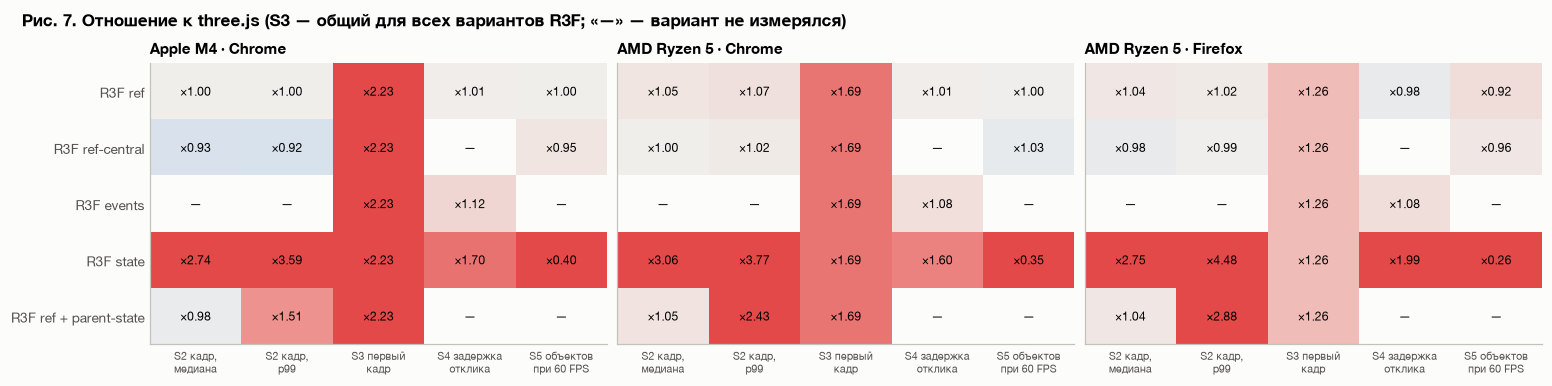

In [12]:
summary_items = [
    ("s2", "frame_ms_median", "S2 кадр,\nмедиана", False),
    ("s2", "frame_ms_p99", "S2 кадр,\np99", False),
    ("s3", "ttfr_submit_ms", "S3 первый\nкадр", False),
    ("s4", "latency_render_ms_median", "S4 задержка\nотклика", False),
    ("s5", "capacity_fps60", "S5 объектов\nпри 60 FPS", True),
]
rows_v = ["r3f-ref", "r3f-ref-central", "r3f-events", "r3f-state", "r3f-ref+parent-state"]
fig, axes = plt.subplots(1, 3, figsize=(14, 3.4), sharey=True)
cmap = plt.matplotlib.colors.LinearSegmentedColormap.from_list("bw", ["#e34948", "#f0a5a0", "#f0efec", "#86b6ef", "#1c5cab"])
all_tabs = []
for ax, (p, title) in zip(axes, PLATFORMS.items()):
    mat = pd.DataFrame(index=rows_v, columns=[s[2] for s in summary_items], dtype=float)
    for sc, m, col, hib in summary_items:
        c = compare(runs, sc, m)
        c = c[c["platform"] == p]
        for _, r in c.iterrows():
            lab = "r3f-ref" if r["label"] == "r3f" else r["label"]  # S3 измеряет всю сборку R3F
            targets = rows_v if r["label"] == "r3f" else [lab]
            for tv in targets:
                if tv in mat.index:
                    mat.loc[tv, col] = r["ratio"]
    good = np.log2(mat.astype(float)) * np.array([1 if s[3] else -1 for s in summary_items])
    ax.imshow(np.clip(good.to_numpy(float), -1, 1), cmap=cmap, vmin=-1, vmax=1, aspect="auto")
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat.iat[i, j]
            ax.text(j, i, "—" if not np.isfinite(v) else f"×{v:.2f}", ha="center", va="center", fontsize=8)
    ax.set_xticks(range(mat.shape[1]), mat.columns, fontsize=7)
    ax.set_title(title)
    ax.grid(False)
    ax.tick_params(length=0)
    all_tabs.append(mat.rename(index=V).assign(платформа=title))
axes[0].set_yticks(range(len(rows_v)), [V[v] for v in rows_v])
fig.suptitle("Рис. 7. Отношение к three.js (S3 — общий для всех вариантов R3F; «—» — вариант не измерялся)",
             x=0.01, ha="left", fontweight="semibold")
P.save(fig, "07_summary")
pd.concat(all_tabs).to_csv(C.TABLE_DIR / "07_summary.csv")

## 8. Что можно добавить при необходимости

Анализ намеренно простой. Если понадобится больше строгости или новые вопросы:

* **тест эквивалентности (TOST)** для H1 — формальная проверка «равны с
  точностью 5%» (сейчас ту же роль играет правило «интервал внутри ±5%»);
* **объединение платформ** в одну оценку (мета-анализ) и оценка того,
  насколько эффект зависит от платформы;
* **стоимость одного объекта** в S5 (наклон кривой, мкс/объект) — удобная
  «цена» для рекомендаций;
* **взвешенная оценка по профилям проектов** (этап 6 плана) — поверх сводной
  таблицы §7;
* **проверки качества данных:** дрейф в течение серии, воспроизводимость
  между сериями на M4 (pilot / dev / preview), выбросы.

In [13]:
C.DATA_DIR.mkdir(exist_ok=True)
runs.drop(columns="file").to_csv(C.DATA_DIR / "runs.csv", index=False)
levels.to_csv(C.DATA_DIR / "levels.csv", index=False)
print("рисунков:", len(list(C.FIG_DIR.glob("*.png"))), "| таблиц:", len(list(C.TABLE_DIR.glob("*.csv"))))

рисунков: 7 | таблиц: 14
